# 5. Recursion and Subdivision

A function that calls itself can split a canvas into ever finer pieces. Today we teach a dozen lines of code to compose in the manner of Piet Mondrian, and then ask the uncomfortable question: what makes one generated composition better than another?

## Today's destination

Six Mondrians nobody painted. Each panel comes from the same recursive system with a different seed; the differences between them are pure chance, and yet you will immediately find some panels stronger than others. That comparison, not any single panel, is today's real artwork, and today's real question.

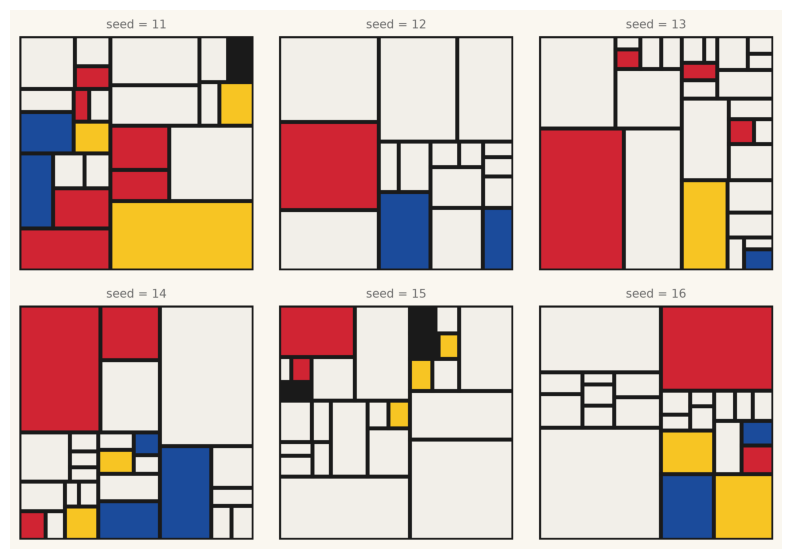

In [1]:
# display this chapter's showpiece (generated by the last cell of this notebook)
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

showpiece_path = "../assets/outputs/ch05_showpiece.png"
if os.path.exists(showpiece_path):
    image = mpimg.imread(showpiece_path)
    plt.figure(figsize=(10, 7))
    plt.imshow(image)
    plt.axis("off")
    plt.show()
else:
    print("Not generated yet -- run the whole notebook once and come back.")

## Context: from tree to grid, and the question of taste

Between 1908 and 1921, **Piet Mondrian** performed one of the most documented abstractions in art history, and he performed it on a tree. *The Red Tree* (1908–10) is still a tree, feverish but recognizable. *The Gray Tree* (1911) keeps the branching but lets go of the leaves and the color. In *Flowering Apple Tree* (1912) the branches have become a field of curved strokes; the motif is dissolving into structure. In *Pier and Ocean* (1915), Mondrian now drawing the sea and a pier rather than the tree, only short horizontal and vertical dashes remain, and from 1920 on Mondrian paints what he is remembered for: white fields, black lines, rectangles of red, yellow, and blue. He called the program **Neoplasticism** (*De Nieuwe Beelding*), and with Theo van Doesburg's journal *De Stijl* (founded 1917) it became a movement. The rules were explicit and severe: horizontals and verticals only, primary colors plus non-colors (white, gray, black), no symmetry, balance instead of repetition. An artist who paints by declared rules is an artist asking to be replaced by a system; it is astonishing how often Mondrian's late work is described, even by admirers, as *algorithmic*.

A generation later, **Barnett Newman** reduced division further: a single vertical "zip" splitting a color field (*Onement I*, 1948). One cut, placed exactly; division itself as the entire composition.

And here the empirical question walks in. In 1966, the engineer **A. Michael Noll** showed people two pictures: Mondrian's *Composition with Lines* (1917) and his own computer imitation of it, made with pseudo-random numbers at Bell Labs. A majority of his participants *preferred* the computer version, and most could not tell which was which. Noll's little study is an ancestor of today's empirical aesthetics, and it sharpens the question this chapter keeps asking: if a program's Mondrian can pass for a Mondrian, where exactly does the artistry live? In the rules? In the tuning of the rules? In the choosing of one output among hundreds? Keep the question warm; you will vote on generated Mondrians yourself before the session ends.

The tool for all of this is **recursion** (Rekursion): a function that calls itself. Mondrian never used the word, but his canvases behave like it: a rectangle divided, the parts divided again, until some part is interesting enough to leave alone.

## A function that calls itself

Recursion sounds like a paradox: how can a function use itself before it is finished being defined? The trick is that each call works on a *smaller* problem, and that some smallest problem is answered without any further call. That escape hatch is the **base case**, and forgetting it is the classic recursion accident (the calls never stop; Python pulls the emergency brake with a `RecursionError`).

The hello-world of recursion is a countdown: to count down from 3, say "3", then count down from 2. The base case is zero.

In [2]:
# the hello-world of recursion: a countdown
def countdown(number):
    if number == 0:            # the base case: stop calling, do something
        print("liftoff!")
        return
    print(number)
    countdown(number - 1)      # the function calls itself, one step smaller

countdown(3)

3
2
1
liftoff!


Python keeps track of the nested calls on a **call stack**: each call waits for the one it started. For `countdown(3)` the stack grows like this:

```
countdown(3)   prints 3
└─ countdown(2)   prints 2
   └─ countdown(1)   prints 1
      └─ countdown(0)   prints "liftoff!"
```

Now the important twist for us: a recursive function may call itself **twice**. Then every call spawns two, those spawn four, and the counts double at every level: after $d$ levels there are up to $2^d$ open ends. This exponential growth is why recursion is so good at generating rich structure from tiny programs, and why a small `depth` parameter goes a long way.

In [3]:
# doubling at every level: why depth is such a powerful parameter
for depth in range(1, 9):
    print("depth", depth, "-> up to", 2 ** depth, "rectangles")

depth 1 -> up to 2 rectangles
depth 2 -> up to 4 rectangles
depth 3 -> up to 8 rectangles
depth 4 -> up to 16 rectangles
depth 5 -> up to 32 rectangles
depth 6 -> up to 64 rectangles
depth 7 -> up to 128 rectangles
depth 8 -> up to 256 rectangles


## Build-up: subdividing a canvas

Our canvas is the unit square: a rectangle described by four numbers `(x, y, width, height)`. The recursive rule, in words:

1. If this rectangle should stay whole: return it (base case).
2. Otherwise split it in two, across its longer side, at a random ratio somewhere near the middle.
3. Ask both halves to subdivide themselves, and pool the results.

When does a rectangle stay whole? We combine three base cases: the recursion has reached its depth limit, or the rectangle has become too small, or **chance says stop**, with probability `stop_chance` per call. That last rule is the compositional heart of the system: it is what makes some regions coarse and others fine, like Mondrian keeping one big field calm while an edge gets busy. With stop probability $p$, each level multiplies the expected number of growing branches ("expected" in the statistician's sense: the average over many runs) by $2(1-p)$; at $p = 0.5$ the system hovers between order and explosion.

One guard rail: chance may only quiet a field that is already smallish (`calm_area`, a quarter of the canvas by default). Without it, the very first call itself could stop with probability $p$: at our default of 0.4, two canvases in five would come out entirely blank. (Whether an all-white canvas *is* a Mondrian is a fine seminar question; as a default behavior it is mostly a bug.)

Randomness is back, so we return to `rng = np.random.default_rng(seed)` from chapter 2, and every seed below is fixed: change any of them for compositions of your own.

In [4]:
# recursive subdivision: returns a list of (x, y, width, height) rectangles
import numpy as np

def subdivide(x, y, width, height, depth, stop_chance, rng,
              min_size=0.1, calm_area=0.25):
    finished = depth == 0 or width < min_size or height < min_size
    may_rest = width * height < calm_area      # only small fields may rest
    if finished or (may_rest and rng.random() < stop_chance):
        return [(x, y, width, height)]         # base case: stay whole
    ratio = rng.uniform(0.35, 0.65)            # split near, not at, the middle
    if width >= height:                        # split across the longer side
        left = subdivide(x, y, width * ratio, height,
                         depth - 1, stop_chance, rng)
        right = subdivide(x + width * ratio, y, width * (1 - ratio), height,
                          depth - 1, stop_chance, rng)
        return left + right
    bottom = subdivide(x, y, width, height * ratio,
                       depth - 1, stop_chance, rng)
    top = subdivide(x, y + height * ratio, width, height * (1 - ratio),
                    depth - 1, stop_chance, rng)
    return bottom + top

rng = np.random.default_rng(1)
rectangles = subdivide(0, 0, 1, 1, depth=3, stop_chance=0.0, rng=rng)
print(len(rectangles), "rectangles; the first one:", np.round(rectangles[0], 3))

8 rectangles; the first one: [0.    0.    0.504 0.25 ]


With `stop_chance=0.0` and depth 3 we get exactly $2^3 = 8$ rectangles. Numbers are not a composition yet; let's see it. We draw each rectangle as a `matplotlib.patches.Rectangle`, the tool you know from chapter 2's color grids: all fields white, black borders, nothing else. Even uncolored, the skeleton already has a temperament.

**Try it:** run the cell, then set `stop_chance` to `0.0` and to `0.7` and run it again; you are turning the system's most important dial.

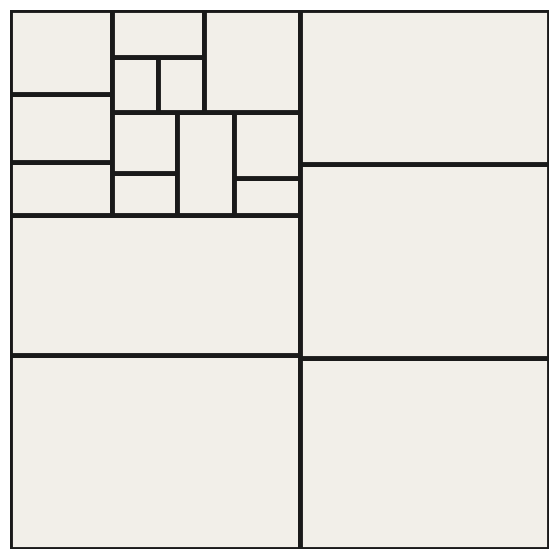

17 rectangles


In [5]:
# render the subdivision skeleton: white fields, black borders
from matplotlib.patches import Rectangle
import sys
sys.path.append("..")
from agap.helpers import PALETTES, PAPER, save_artwork

rng = np.random.default_rng(7)
rectangles = subdivide(0, 0, 1, 1, depth=7, stop_chance=0.4, rng=rng)

fig, ax = plt.subplots(figsize=(7, 7))
for x, y, width, height in rectangles:
    ax.add_patch(Rectangle((x, y), width, height, facecolor="#F2EFE9",
                           edgecolor="#1A1A1A", linewidth=3.5))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.axis("off")
plt.show()
print(len(rectangles), "rectangles")

## Color, rationed

Now the paint. Mondrian's economy is strict: most fields stay white; red, blue, and yellow appear as counterweights, and small black planes are the rarest events of all. That is a **weighted choice**, exactly the tool from chapter 2, and conveniently our `bauhaus` palette holds the right five colors in order: red, blue, yellow, near-black, and an off-white for the ground.

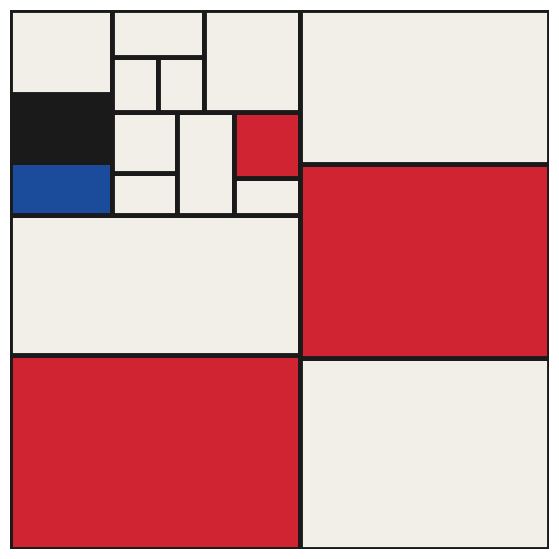

In [6]:
# weighted coloring: mostly white fields, primaries as counterweights
color_weights = [0.10, 0.08, 0.07, 0.03, 0.72]   # red, blue, yellow, black, white

rng = np.random.default_rng(7)
rectangles = subdivide(0, 0, 1, 1, depth=7, stop_chance=0.4, rng=rng)

fig, ax = plt.subplots(figsize=(7, 7))
for x, y, width, height in rectangles:
    index = rng.choice(len(PALETTES["bauhaus"]), p=color_weights)
    ax.add_patch(Rectangle((x, y), width, height,
                           facecolor=PALETTES["bauhaus"][index],
                           edgecolor="#1A1A1A", linewidth=3.5))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.axis("off")
plt.show()

## The dials of the system

Two parameters shape the composition's character more than any others. `stop_chance` sets the grain: high values stop the splitting early (few large, calm fields), low values let it run deep (nervous lattices). And the border `linewidth` changes the work's voice completely; Mondrian himself fussed endlessly over the widths of his black lines, which are painted planes, not drawn lines. Compare:

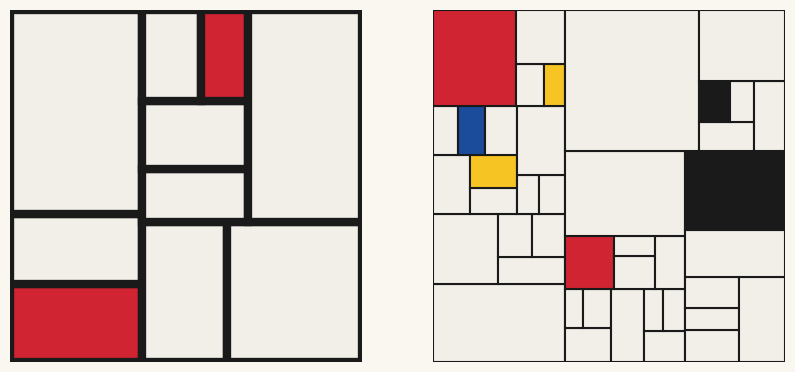

In [7]:
# same system, different dials: calm and bold vs deep and wiry
def draw_composition(ax, depth, stop_chance, border, weights, seed):
    rng = np.random.default_rng(seed)
    for x, y, width, height in subdivide(0, 0, 1, 1, depth, stop_chance, rng):
        index = rng.choice(len(PALETTES["bauhaus"]), p=weights)
        ax.add_patch(Rectangle((x, y), width, height,
                               facecolor=PALETTES["bauhaus"][index],
                               edgecolor="#1A1A1A", linewidth=border))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.axis("off")

fig, axes = plt.subplots(1, 2, figsize=(10, 5), facecolor=PAPER)
draw_composition(axes[0], depth=5, stop_chance=0.55, border=6, weights=color_weights, seed=3)
draw_composition(axes[1], depth=9, stop_chance=0.25, border=1.5, weights=color_weights, seed=3)
plt.show()

Same seed, same random sequence: every difference between the two panels comes from the dials. Notice how the thin-lined version stops looking like Mondrian and starts looking like a city map; parameters carry style.

## Playground

The finished generator, and the sheet function that makes today's showpiece: a 2 × 3 grid of compositions from six different seeds. Since `draw_composition` paints onto an axis we hand it, building the sheet is just a loop over subplots.

In [8]:
# the finished generator: one Mondrian-style composition
def mondrian(depth=7, stop_chance=0.4, border=3.5, weights=None, seed=7):
    if weights is None:
        weights = [0.10, 0.08, 0.07, 0.03, 0.72]
    fig, ax = plt.subplots(figsize=(7, 7), facecolor=PAPER)
    draw_composition(ax, depth, stop_chance, border, weights, seed)
    plt.show()
    return fig

# a sheet of six: the comparison is the artwork
def mondrian_sheet(seeds, depth=7, stop_chance=0.4, border=3, weights=None):
    if weights is None:
        weights = [0.10, 0.08, 0.07, 0.03, 0.72]
    fig, axes = plt.subplots(2, 3, figsize=(10.5, 7), facecolor=PAPER)
    for i in range(6):
        ax = axes[i // 3, i % 3]      # row = i // 3, column = i % 3
        draw_composition(ax, depth, stop_chance, border, weights, seeds[i])
        ax.set_title(f"seed = {seeds[i]}", fontsize=9, color="#6B6B6B")
    fig.subplots_adjust(wspace=0.08, hspace=0.15)
    plt.show()
    return fig

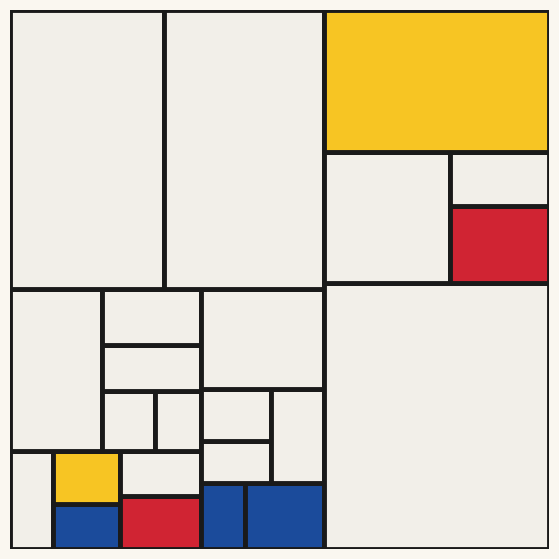

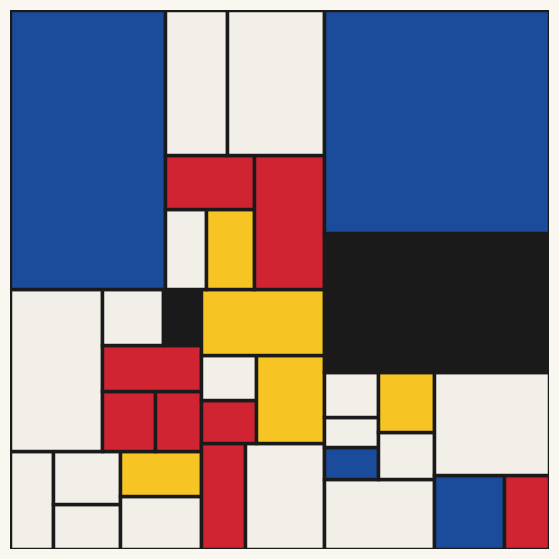

In [9]:
# temperament 1 and 2: a single composition, then a variation with more color
art_1 = mondrian(depth=7, stop_chance=0.4, border=3.5, seed=42)
art_2 = mondrian(depth=8, stop_chance=0.3, border=2.5,
                 weights=[0.18, 0.15, 0.12, 0.05, 0.50], seed=42)

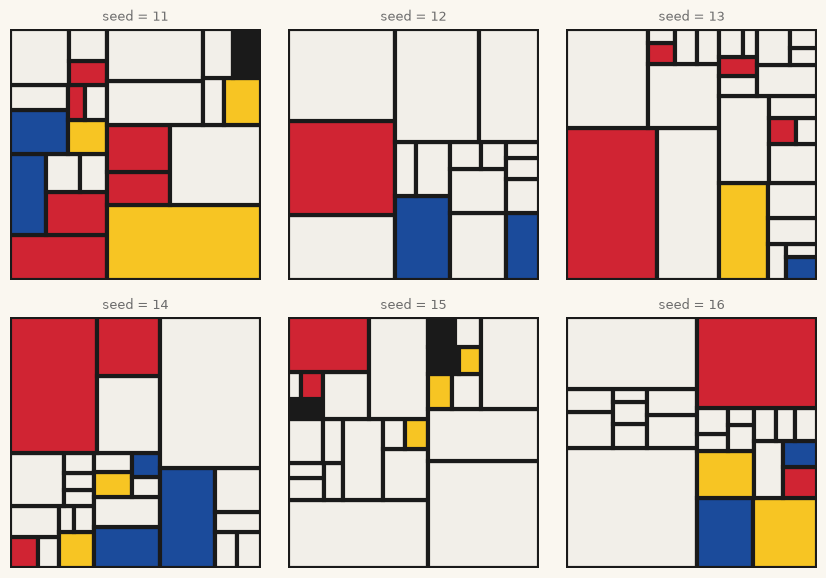

In [10]:
# temperament 3: the sheet -- six seeds, one system
art_3 = mondrian_sheet(seeds=[11, 12, 13, 14, 15, 16])

**Look and compare.** Rank the six panels of the sheet from strongest to weakest before talking to your neighbor, then compare rankings. Where you agree: can you name the property? (A dominant calm field? A well-placed red?) Where you disagree, you have found the part of aesthetics that the parameters do not reach. And a harder question, Noll's question: if we generated 500 sheets and *you* picked the best panel, who composed it: the algorithm, the seed, or you?

## Bonus: the tree, run backwards

Mondrian walked from tree to grid; our recursion can walk the other way. The same self-calling pattern that split rectangles can grow branches: draw a line, then grow two smaller lines from its tip, rotated left and right. The angles come from chapter 3's trigonometry. This doodle is a preview: in chapter 7 a much more powerful grammar for plants, the L-system, grows whole gardens from three rules.

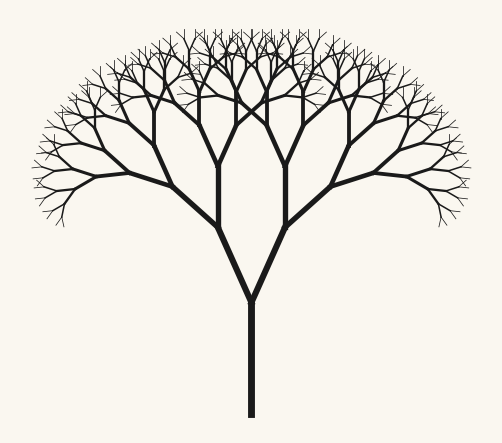

In [11]:
# a branch draws itself, then asks two smaller branches to do the same
import math

def branch(ax, x, y, angle, length, depth):
    if depth == 0:
        return                              # base case: the twig ends
    x_tip = x + length * math.cos(angle)
    y_tip = y + length * math.sin(angle)
    ax.plot([x, x_tip], [y, y_tip], color="#1A1A1A", linewidth=depth * 0.55)
    branch(ax, x_tip, y_tip, angle + 0.42, length * 0.74, depth - 1)
    branch(ax, x_tip, y_tip, angle - 0.42, length * 0.74, depth - 1)

fig, ax = plt.subplots(figsize=(7, 5.5), facecolor=PAPER)
branch(ax, 0, 0, math.pi / 2, 1.0, depth=9)
ax.set_aspect("equal")
ax.axis("off")
plt.show()

## Export your artwork

Generate sheets until one panel feels right, then export either a single composition or a whole sheet. Replace `yourname` and run; the print-quality PNG lands in `assets/outputs/`.

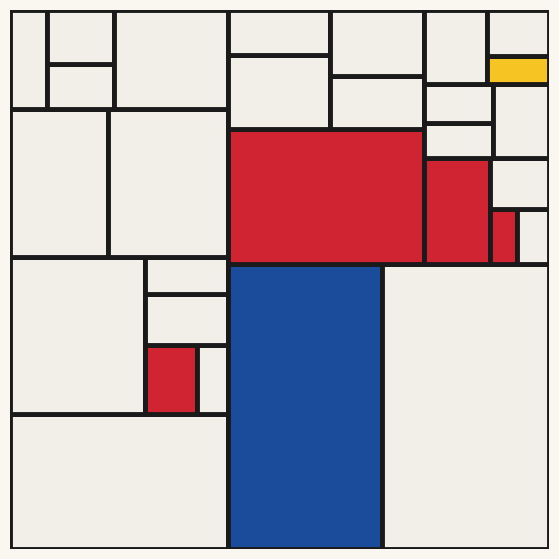

saved: assets/outputs/ch05_yourname.png


In [12]:
# save YOUR artwork: adjust parameters, replace 'yourname', run the cell
my_artwork = mondrian(depth=7, stop_chance=0.4, border=3.5, seed=2026)
saved_path = save_artwork(my_artwork, "yourname", chapter=5)

## Exercises

**(a) Parameter exploration: fool a friend.** Tune `depth`, `stop_chance`, `border`, and the color weights until a composition could hang in a museum's Mondrian room without raising suspicion. Test it on someone outside this course, next to a photo of a real one (*Composition with Red, Blue and Yellow*, 1930, is easy to find), and bring your best forgery to the next session. Which parameter did the fooling?

**(b) Code modification: lonely colors.** In real Mondrians, colored planes rarely touch each other; white keeps them apart. Enforce it: **no colored rectangle may share an edge with another colored rectangle.** Assign colors one rectangle at a time, remember which rectangles got color, and when a candidate would touch one of them, paint it white instead. Two axis-aligned rectangles share an edge if they touch along x and overlap along y, or the other way around.

<details><summary>Solution</summary>

```python
def touching(a, b):
    ax_, ay, aw, ah = a
    bx, by, bw, bh = b
    beside = abs(ax_ + aw - bx) < 1e-9 or abs(bx + bw - ax_) < 1e-9
    overlap_y = ay < by + bh - 1e-9 and by < ay + ah - 1e-9
    stacked = abs(ay + ah - by) < 1e-9 or abs(by + bh - ay) < 1e-9
    overlap_x = ax_ < bx + bw - 1e-9 and bx < ax_ + aw - 1e-9
    return (beside and overlap_y) or (stacked and overlap_x)

def mondrian_lonely(depth=7, stop_chance=0.4, border=3.5, seed=7):
    weights = [0.10, 0.08, 0.07, 0.03, 0.72]
    rng = np.random.default_rng(seed)
    rectangles = subdivide(0, 0, 1, 1, depth, stop_chance, rng)
    fig, ax = plt.subplots(figsize=(7, 7))
    colored = []
    for rect in rectangles:
        index = rng.choice(len(PALETTES["bauhaus"]), p=weights)
        if index != 4:                        # a colored candidate...
            for other in colored:
                if touching(rect, other):     # ...touching a colored one?
                    index = 4                 # then white after all
                    break
        if index != 4:
            colored.append(rect)
        ax.add_patch(Rectangle((rect[0], rect[1]), rect[2], rect[3],
                               facecolor=PALETTES["bauhaus"][index],
                               edgecolor="#1A1A1A", linewidth=border))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.show()
    return fig

art = mondrian_lonely(seed=7)
```

The `1e-9` tolerances guard against floating-point fuzz: two rectangles born from one split share an edge *exactly*, but arithmetic on those coordinates can be off by a hair's breadth. Compare the same seed with and without the rule; the constrained version usually breathes more.
</details>

**(c) Creative challenge: change the cut.** Our system only knows straight, axis-aligned cuts, Mondrian's dogma. Break it: subdivide with circles (each level draws a ring of smaller circles inside), or allow diagonal cuts at ±45°, or split rectangles into three parts instead of two. One changed rule, a completely different artist. Give the result a manifesto sentence, De Stijl style.

## Further reading

- A. Michael Noll, "Human or Machine: A Subjective Comparison of Piet Mondrian's *Composition with Lines* (1917) and a Computer-Generated Picture", *The Psychological Record* 16 (1966): the founding experiment; Noll hosts his computer-art papers on [his own site](https://noll.uscannenberg.org/).
- Meyer Schapiro, "Mondrian: Order and Randomness in Abstract Painting", in *Modern Art: 19th and 20th Centuries* (1978): a great art historian on exactly our chapter title.
- The [Kunstmuseum Den Haag](https://www.kunstmuseum.nl/en/collections/piet-mondriaan), home of the world's largest Mondrian collection: browse the tree series in order and watch the abstraction happen.
- Daniel Shiffman, [*The Nature of Code*, chapter on fractals](https://natureofcode.com/fractals/): recursion continued into self-similar territory, where our chapter 8 also goes.

---
### Appendix: regenerate the showpiece

This last cell (re)creates the image shown at the top of the notebook. It runs automatically with *Restart & Run All*.

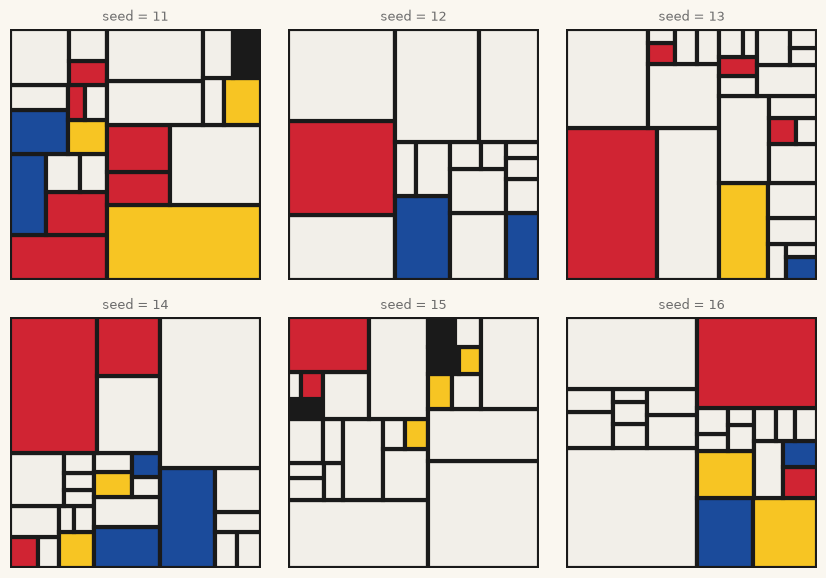

saved: assets/outputs/ch05_showpiece.png


In [13]:
# regenerate this chapter's showpiece: a sheet of six compositions
showpiece = mondrian_sheet(seeds=[11, 12, 13, 14, 15, 16])
saved_path = save_artwork(showpiece, "showpiece", chapter=5)